# iLILA reference noise and additional noise allowance
**Kaylah McGowan | First calculation | 24 September 2026**

This notebook implements the thermal, shot, and dust displacement-noise terms in the supplied **Creighton et al., _Fundamental Noise and Gravitational-Wave Sensitivity of the Laser Interferometer Lunar Antenna (LILA)_, `LILAL-noise.pdf`**, Eqs. (2)–(5). It then calculates how much additional independent noise a chosen displacement target permits.

**Scope:** a reproducible reference calculation, not a validated instrument noise budget or a reproduction of the resonant strain curve in Figure 3. Lunar seismic spectra, support dynamics, technical noise, radiation degradation, and science SNR remain unmodeled here. Their absence is not evidence that they are negligible.

All plotted spectra are one-sided. The scalar displacement coordinate follows the paper's $S_x$ convention. Before applying these allocations to a hardware readout, reconcile optical-path versus one-way differential-displacement conventions and per-optic versus aggregate noise factors. No additional factor of two or number-of-mirrors multiplier is silently introduced.

Run cells in order. Dependencies: Python 3, NumPy, pandas, Matplotlib. The notebook is self-contained and does not require Finesse or Fintrace. Plot cells also save high-resolution PNGs in the working directory.

## Reference assumptions

| Parameter | Value used | Source or status |
|---|---:|---|
| Arm length | 1,000 m | Supplied manuscript, Sections 1 and 4 |
| Wavelength | 1,064 nm | Eq. (4); separate from 1,550 nm laboratory configuration |
| Temperature | 300 K | Eqs. (2)–(3) reference |
| Optimistic thermal PSD at 1 Hz | $1.2\times10^{-33}$ m²/Hz | Eq. (3) |
| Conservative thermal PSD at 1 Hz | $6.0\times10^{-32}$ m²/Hz | Eq. (2), an alternative, not an extra term |
| Effective detected power $\eta P$ | 0.5 W | Interpretation of Section 4's 500 mW photodiodes; confirm quantum efficiency and losses |
| Dust PSD at 5 km | $1.6\times10^{-35}$ m²/Hz | Rounded scaling in Eq. (5), rescaled to 1 km |
| Dust density, grain radius, speed | 0.003 m⁻³, 0.7 μm, 300 m/s | Eq. (5) reference assumptions |
| Beam width for dust estimate | 1 cm | Eq. (5); not the narrowest spot for thermal noise |
| Flat displacement target | $10^{-15}$ m/√Hz over 1–100 mHz | Preliminary target carried in the project plan; not the paper's strain curve |

**Two targets will be compared:** the preliminary flat displacement target and an explicitly illustrative envelope 10% above the calculated reference ASD. The latter is a sensitivity study, not an approved requirement. Changing the envelope changes the available noise allocation.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

C = 299792458.0
H = 6.62607015e-34
HBAR = H / (2*np.pi)
P = dict(
    arm_length_m=1000.0,
    wavelength_m=1064e-9,
    temperature_K=300.0,
    thermal_optimistic_psd_1Hz=1.2e-33,
    thermal_conservative_psd_1Hz=6.0e-32,
    effective_detected_power_W=0.5,
    dust_reference_psd=1.6e-35,
    dust_density_m3=3e-3,
    dust_radius_m=0.7e-6,
    dust_speed_ms=300.0,
    dust_beam_width_m=0.01,
    flat_target_asd=1e-15,
    illustrative_asd_multiplier=1.10,
)
f = np.geomspace(1e-4, 1.0, 2401)
plt.rcParams.update({
    'font.size':11, 'axes.labelsize':12, 'axes.titlesize':14,
    'axes.spines.top':False, 'axes.spines.right':False,
    'figure.facecolor':'white', 'axes.facecolor':'white',
    'savefig.facecolor':'white',
})
print('Reference: 1 km, 1064 nm, 300 K, eta P = 0.5 W')

Reference: 1 km, 1064 nm, 300 K, eta P = 0.5 W


## Implement the paper's displacement terms

$$S_{x,T}(f)=A_T\frac{T}{300\,\mathrm{K}}\left(\frac{f}{1\,\mathrm{Hz}}\right)^{-1},\qquad
S_{x,\mathrm{shot}}=\frac{\hbar c\lambda}{2\pi\eta P}.$$

Dust uses the rounded numerical scaling in Eq. (5). Under the reference assumptions it is frequency independent. The formula's generality should be revisited for site-specific dust and beam geometry.

For this reference calculation, assume the three terms are mutually independent and sum their **PSDs**, then take the square root. The two thermal cases are alternatives. We do not add a separate substrate curve to the aggregate thermal normalization without establishing that it represents a distinct contribution.

In [2]:
def reference_psds(freq, parameters=P):
    freq = np.asarray(freq, dtype=float)
    if np.any(~np.isfinite(freq)) or np.any(freq <= 0):
        raise ValueError('Frequencies must be finite and positive.')
    for key, value in parameters.items():
        if not np.isfinite(value) or value <= 0:
            raise ValueError(f'{key} must be finite and positive.')
    p = parameters
    thermal = p['thermal_optimistic_psd_1Hz']*(p['temperature_K']/300)/freq
    conservative = p['thermal_conservative_psd_1Hz']*(p['temperature_K']/300)/freq
    shot = np.full_like(freq, HBAR*C*p['wavelength_m']/(2*np.pi*p['effective_detected_power_W']))
    dust = np.full_like(freq,
        p['dust_reference_psd']*(p['arm_length_m']/5000)
        *(p['dust_density_m3']/3e-3)*(p['dust_radius_m']/0.7e-6)**6
        *(300/p['dust_speed_ms'])*(0.01/p['dust_beam_width_m']))
    return {'thermal':thermal, 'thermal_conservative':conservative,
            'shot':shot, 'dust':dust,
            'reference':thermal+shot+dust,
            'reference_conservative':conservative+shot+dust}

S = reference_psds(f)
check_f = np.array([0.001, 0.01, 0.1, 1.0])
check = reference_psds(check_f)
reference_table = pd.DataFrame({
    'frequency_Hz':check_f,
    **{name+'_ASD_m_rtHz':np.sqrt(check[name])
       for name in ['thermal','shot','dust','reference','reference_conservative']}
})
print(reference_table.to_string(index=False, float_format=lambda x:f'{x:.4e}'))

 frequency_Hz  thermal_ASD_m_rtHz  shot_ASD_m_rtHz  dust_ASD_m_rtHz  reference_ASD_m_rtHz  reference_conservative_ASD_m_rtHz
   1.0000e-03          1.0954e-15       1.0348e-16       1.7889e-18            1.1003e-15                         7.7467e-15
   1.0000e-02          3.4641e-16       1.0348e-16       1.7889e-18            3.6154e-16                         2.4517e-15
   1.0000e-01          1.0954e-16       1.0348e-16       1.7889e-18            1.5070e-16                         7.8148e-16
   1.0000e+00          3.4641e-17       1.0348e-16       1.7889e-18            1.0914e-16                         2.6591e-16


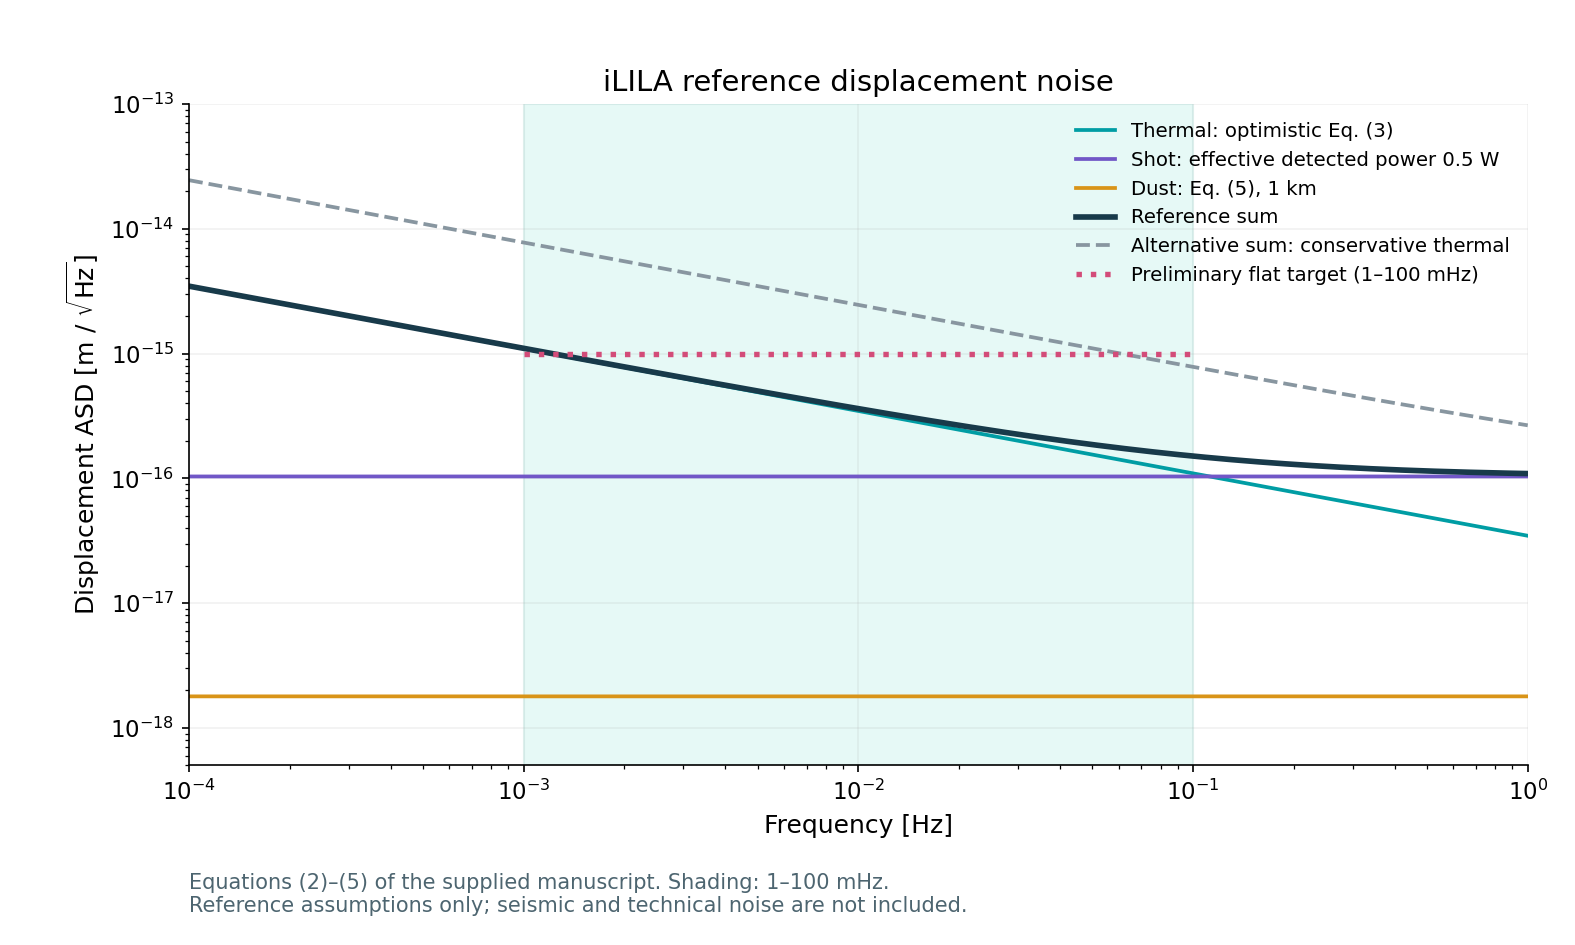

In [3]:
fig, ax = plt.subplots(figsize=(10.5, 6.3))
ax.axvspan(1e-3, 1e-1, color='#C8F2ED', alpha=.45, zorder=0)
styles = [
    ('thermal','Thermal: optimistic Eq. (3)','#009DA4','-'),
    ('shot','Shot: effective detected power 0.5 W','#7157C7','-'),
    ('dust','Dust: Eq. (5), 1 km','#D99418','-'),
    ('reference','Reference sum','#183A4A','-'),
    ('reference_conservative','Alternative sum: conservative thermal','#8896A0','--')]
for key, label, color, ls in styles:
    ax.loglog(f, np.sqrt(S[key]), label=label, color=color, ls=ls,
              lw=2.7 if key=='reference' else 1.8)
ax.loglog([1e-3,1e-1],[P['flat_target_asd']]*2, color='#D34C79',ls=':',lw=2.6,
          label='Preliminary flat target (1–100 mHz)')
ax.set(xlabel='Frequency [Hz]', ylabel=r'Displacement ASD [m / $\sqrt{\mathrm{Hz}}$]',
       title='iLILA reference displacement noise', xlim=(1e-4,1), ylim=(5e-19,1e-13))
ax.grid(True, which='major', alpha=.18)
ax.legend(loc='upper right', fontsize=9.5, frameon=False)
fig.text(.12,.035,'Equations (2)–(5) of the supplied manuscript. Shading: 1–100 mHz.\n'
         'Reference assumptions only; seismic and technical noise are not included.', fontsize=10,color='#4D6570')
fig.subplots_adjust(left=.12,right=.97,bottom=.19,top=.89)
fig.savefig('iLILA_Reference_Displacement_Budget.png', dpi=200)
plt.show()

## Work backward from a target

For mutually independent terms in the same calibrated coordinate,
$$S_{x,\mathrm{additional,max}}(f)=S_{x,\mathrm{target}}(f)-S_{x,\mathrm{reference}}(f).$$

A negative result means the reference already exceeds the target. It is flagged as **infeasible**, not silently clipped to a zero-noise requirement. A zero result means there is no additional allowance.

This allowance must cover **all omitted independent terms together**: seismic residuals, laser noise, thermal drift, alignment, electronics, controls, and degradation effects. It is an upper ceiling for seismic only if those other terms consume none of it. Once a credible nonseismic technical PSD is available, subtract it too. Correlated terms require the full cross-spectral budget rather than this scalar subtraction.

If the target is exactly the reference curve, no additional independent noise can be added while keeping that curve unchanged. For an illustrative allowed ASD increase $g$, the additional allowance is $\sqrt{g^2-1}$ times the reference ASD. This specifies a tolerance; it does not establish that mitigation can achieve it.

In [4]:
def additional_allowance(target_asd, reference_psd, other_known_psd=None):
    target_asd, reference_psd = np.broadcast_arrays(
        np.asarray(target_asd,dtype=float), np.asarray(reference_psd,dtype=float))
    if np.any(~np.isfinite(target_asd)) or np.any(target_asd < 0):
        raise ValueError('Target ASD must be finite and nonnegative.')
    if np.any(~np.isfinite(reference_psd)) or np.any(reference_psd < 0):
        raise ValueError('Reference PSD must be finite and nonnegative.')
    # None means the result is the ceiling for ALL omitted terms, not a full budget.
    other = np.zeros_like(reference_psd) if other_known_psd is None else np.broadcast_to(
        np.asarray(other_known_psd,dtype=float), reference_psd.shape)
    if np.any(~np.isfinite(other)) or np.any(other < 0):
        raise ValueError('Known independent technical PSD must be finite and nonnegative.')
    signed = target_asd**2-reference_psd-other
    feasible = signed >= 0
    asd = np.sqrt(np.where(feasible,signed,np.nan))
    return signed, asd, feasible

band = (f>=1e-3)&(f<=1e-1)
fb, Sb = f[band], S['reference'][band]
flat_signed, flat_allowance, flat_ok = additional_allowance(P['flat_target_asd'],Sb)
g = P['illustrative_asd_multiplier']
relative_allowance = np.sqrt((g*g-1)*Sb)
white_psd = float(check['shot'][0]+check['dust'][0])
denom = P['flat_target_asd']**2-white_psd
crossing_Hz = (P['thermal_optimistic_psd_1Hz']*(P['temperature_K']/300)/denom
               if denom>0 else np.inf)
print(f'Optimistic reference at 1 mHz: {np.sqrt(check["reference"][0]):.4e} m/sqrt(Hz)')
print(f'Flat-target crossing: {crossing_Hz*1000:.4f} mHz')
print(f'Illustrative {100*(g-1):.1f}% ASD increase permits additional ASD = '
      f'{np.sqrt(g*g-1):.4f} times reference ASD.')
signed, allowed, feasible = additional_allowance(P['flat_target_asd'],check['reference'][:3])
allowance_table = pd.DataFrame({
    'frequency_Hz':check_f[:3], 'flat_target_feasible':feasible,
    'remaining_PSD_m2_Hz':signed, 'additional_ASD_ceiling_m_rtHz':allowed})
print(allowance_table.to_string(index=False, float_format=lambda x:f'{x:.4e}'))

Optimistic reference at 1 mHz: 1.1003e-15 m/sqrt(Hz)
Flat-target crossing: 1.2130 mHz
Illustrative 10.0% ASD increase permits additional ASD = 0.4583 times reference ASD.
 frequency_Hz  flat_target_feasible  remaining_PSD_m2_Hz  additional_ASD_ceiling_m_rtHz
   1.0000e-03                 False          -2.1071e-31                            NaN
   1.0000e-02                  True           8.6929e-31                     9.3236e-16
   1.0000e-01                  True           9.7729e-31                     9.8858e-16


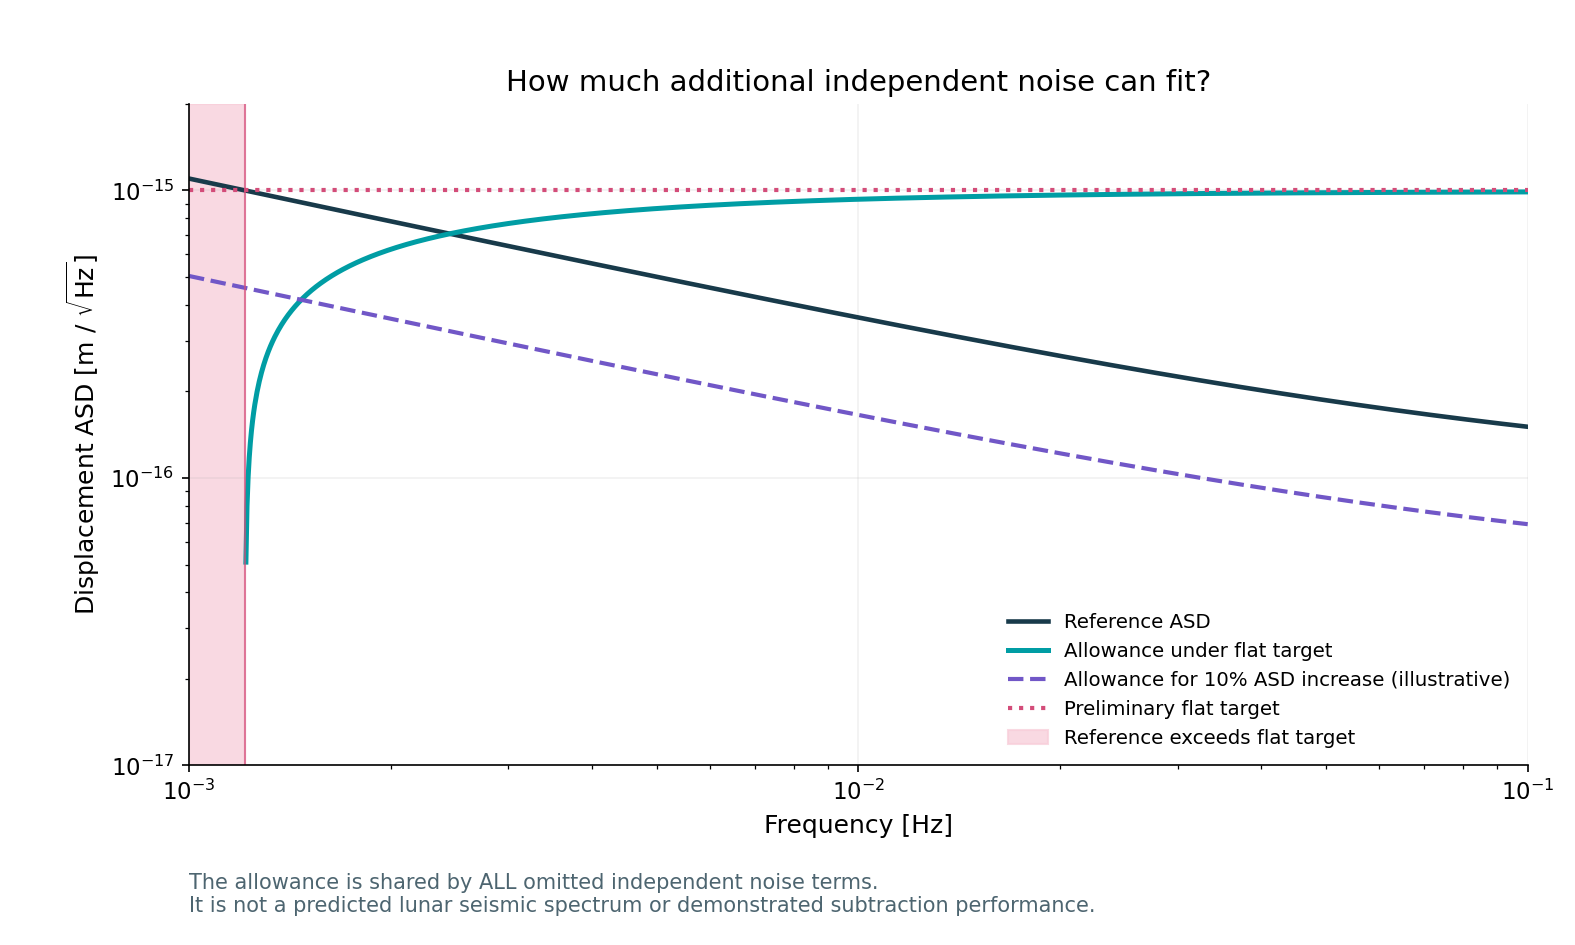

In [5]:
fig, ax = plt.subplots(figsize=(10.5,6.3))
ax.loglog(fb,np.sqrt(Sb),color='#183A4A',lw=2.2,label='Reference ASD')
ax.loglog(fb,flat_allowance,color='#009DA4',lw=2.4,label='Allowance under flat target')
ax.loglog(fb,relative_allowance,color='#7157C7',lw=2,ls='--',
          label=f'Allowance for {100*(g-1):.0f}% ASD increase (illustrative)')
ax.loglog([1e-3,1e-1],[P['flat_target_asd']]*2,ls=':',color='#D34C79',lw=2,
          label='Preliminary flat target')
if crossing_Hz > 1e-3:
    ax.axvspan(1e-3,min(crossing_Hz,1e-1),color='#F8CDD9',alpha=.75,
               label='Reference exceeds flat target')
if 1e-3 < crossing_Hz < 1e-1:
    ax.axvline(crossing_Hz,color='#D34C79',lw=1,alpha=.7)
ax.set(xlabel='Frequency [Hz]',ylabel=r'Displacement ASD [m / $\sqrt{\mathrm{Hz}}$]',
       title='How much additional independent noise can fit?',xlim=(1e-3,1e-1),ylim=(1e-17,2e-15))
ax.grid(True,which='major',alpha=.18)
ax.legend(loc='lower right',fontsize=9.5,frameon=False)
fig.text(.12,.035,'The allowance is shared by ALL omitted independent noise terms.\n'
         'It is not a predicted lunar seismic spectrum or demonstrated subtraction performance.',fontsize=10,color='#4D6570')
fig.subplots_adjust(left=.12,right=.97,bottom=.19,top=.89)
fig.savefig('iLILA_Additional_Noise_Allowance.png',dpi=200)
plt.show()

## Start the seismic coupling model with geometry

For a right-angle Michelson, define $x=\delta L_X-\delta L_Y$ using one-way arm changes. In the low-frequency rigid-following limit,
$$x=(u_{E_X,x}-u_{C,x})-(u_{E_Y,y}-u_{C,y}).$$

For $\mathbf u=(u_{E_X,x},u_{E_Y,y},u_{C,x},u_{C,y})$, the geometric coupling row is $\mathbf c=(1,-1,-1,1)$ and $S_x=\mathbf c S_u\mathbf c^\dagger$. A common rigid translation cancels. Equal, mutually uncorrelated displacement spectra in the four coordinates instead give $S_x=4S_u$. These are algebraic limit checks, not claims about lunar coherence.

The actual coupling row must include ground-to-optic translation/rotation dynamics, optical calibration, and scattering paths. Rotations, unequal supports and their resonances are not represented below. This is the first geometry check before adding those models.

In [6]:
cgeom = np.array([1.,-1.,-1.,1.])
def differential_psd(coupling, cross_psd):
    coupling = np.asarray(coupling,dtype=complex)
    matrix = np.asarray(cross_psd,dtype=complex)
    if matrix.shape != (coupling.size,coupling.size):
        raise ValueError('Cross-PSD matrix shape must match coupling vector.')
    scale = max(float(np.max(np.abs(matrix))),np.finfo(float).tiny)
    if not np.allclose(matrix/scale,(matrix/scale).conj().T,rtol=1e-9,atol=1e-12):
        raise ValueError('Cross-PSD matrix must be Hermitian.')
    if np.linalg.eigvalsh(matrix/scale).min() < -1e-10:
        raise ValueError('Cross-PSD matrix must be positive semidefinite.')
    value = coupling@matrix@coupling.conj()
    return max(float(value.real),0.)

# Normalized tests: PSD=1 in arbitrary displacement units.
independent = np.eye(4)
common_x = np.array([1.,0.,1.,0.])
common_y = np.array([0.,1.,0.,1.])
rigid_translation = np.outer(common_x,common_x)+np.outer(common_y,common_y)
print('Independent-coordinate factor:',differential_psd(cgeom,independent))
print('Rigid-translation factor:',differential_psd(cgeom,rigid_translation))
print('No lunar ground-motion amplitude or subtraction factor has been assigned.')

Independent-coordinate factor: 4.0
Rigid-translation factor: 0.0
No lunar ground-motion amplitude or subtraction factor has been assigned.


## Analytic optical calibration for the next Finesse step

For the same one-way differential displacement, $\delta\phi=4\pi\delta x/\lambda$. At frequencies well below the arm propagation scale, frequency noise couples as $\delta x_\nu=\Delta L\,\delta\nu/\nu_0$, with $\Delta L=L_X-L_Y$ the one-way mismatch. These are analytic limits to test against a future calibrated simulation.

For an ideal lossless Michelson with total interference power $P_0$, $P_{AS}=P_0(1-\cos\phi)/2$, so $dP_{AS}/dx=(2\pi P_0/\lambda)\sin\phi$. The linear direct-power gain vanishes at exact dark fringe. The actual readout must specify a local oscillator, modulation/demodulation, or a deliberate operating-point offset before reporting sensitivity in detector units.

In [7]:
nu0 = C/P['wavelength_m']
phase_gain = 4*np.pi/P['wavelength_m']
example_mismatch_m = 0.01  # illustrative sweep point, not measured
example_allocation_asd = 1e-16  # separate example allocation, not approved
frequency_requirement = example_allocation_asd*nu0/abs(example_mismatch_m)
print(f'Phase gain: {phase_gain:.4e} rad/m')
print(f'Example: 1 cm mismatch and 1e-16 m/sqrt(Hz) frequency-noise allocation')
print(f'require frequency ASD <= {frequency_requirement:.4g} Hz/sqrt(Hz).')

Phase gain: 1.1810e+07 rad/m
Example: 1 cm mismatch and 1e-16 m/sqrt(Hz) frequency-noise allocation
require frequency ASD <= 2.818 Hz/sqrt(Hz).


## Checks and current limitations

The checks below verify analytic scaling, the quoted rounded shot-noise normalization, negative-margin handling, and the common-translation seismic limit. They do not validate lunar input spectra or the final instrument.

Source audit:

- `run_michelson_gouy (4)(1).py` and `run_michelson_gouy_fixed(1).py` produce layout and Gaussian-beam diagnostics, not displacement/readout transfer functions. Both currently select `simple_michelson.yaml`.
- `simple_michelson.yaml` uses 1064 nm, a 0.5 mm input radius, and 0.5 m coordinate arms. The separate `simple_michelson_1550nm.yaml` uses a provisional 1.25 mm radius. Its power and geometry remain idealized assumptions, not measured bench values.
- The fixed runner aliases an unavailable `AstigmaticLens` to `Lens`. That compatibility workaround is not validation of an astigmatic optical element.
- `lila_pioneer_noise_budget_V2.py` has assumed technical-noise terms and an illustrative seismic-subtraction curve; the seismic curve is not included in its instrument total. Retain it as exploratory work, not measured performance.
- This session has not rerun Finesse/Fintrace: those packages are unavailable in the execution environment. This notebook's analytic calculations were executed independently.

**Next inputs:** numerical reference curves; mode frequencies and quality factors used by Teviet; confirmed effective detected power; the intended displacement/readout convention; and the actual laboratory readout choice. The mode table is necessary for an exact reproduction of the resonant response. Do not invent mode frequencies to make a matching-looking curve.

Before reporting science SNR, specify the source, waveform normalization, observing time, orientation and required SNR. A displacement allowance alone does not establish the SNR target.

In [8]:
assert np.isclose(reference_psds([1.])['thermal'][0],1.2e-33,rtol=1e-12,atol=0)
assert np.isclose(reference_psds([.01])['thermal'][0]/reference_psds([.1])['thermal'][0],10)
twice = dict(P,effective_detected_power_W=2*P['effective_detected_power_W'])
assert np.isclose(reference_psds([.1],twice)['shot'][0]/check['shot'][0],.5)
double_L = dict(P,arm_length_m=2*P['arm_length_m'])
assert np.isclose(reference_psds([.1],double_L)['dust'][0]/check['dust'][0],2)
at_100mW = reference_psds([1.],dict(P,effective_detected_power_W=.1))['shot'][0]
assert np.isclose(at_100mW,5.4e-32,rtol=.01,atol=0)
_, no_allowance, ok = additional_allowance(1e-15,np.array([1.2e-30]))
assert not ok[0] and np.isnan(no_allowance[0])
assert differential_psd(cgeom,independent)==4
assert differential_psd(cgeom,rigid_translation)==0
assert np.isclose(reference_psds([crossing_Hz])['reference'][0],P['flat_target_asd']**2,rtol=1e-12,atol=0)
print('Passed: thermal, power and arm-length scaling; rounded Eq. (4) normalization;')
print('negative-margin flag; seismic geometry limits; analytic target crossing.')

Passed: thermal, power and arm-length scaling; rounded Eq. (4) normalization;
negative-margin flag; seismic geometry limits; analytic target crossing.


## Source provenance

Calculations use the supplied manuscript received 24 September 2026, not an assumed public revision.

`LILAL-noise.pdf` SHA-256: `df1c342fb3ade52d5ebdccf9f4d4c0c8ef6e1890b019518f96eb4aae42393261`.

The preliminary flat target comes from the current project plan and V2 README. Numerical outputs in this notebook are newly calculated from the stated equations and assumptions.

## Next calculation — laser frequency noise and arm mismatch

This calculation converts the reference allowance into a **conditional laser-frequency-noise requirement**. It remains an analytic benchmark for the optical model. It does not assume a measured laser spectrum or claim that Finesse has been run.

Define $x=\delta L_X-\delta L_Y$ as one-way differential displacement, $\Delta L=L_X-L_Y$ as static one-way arm mismatch, and $\nu_0=c/\lambda$. For an ideal vacuum Michelson at frequencies well below the propagation scale,

$$H_{x\nu}=\frac{\Delta L}{\nu_0},\qquad
A_{x,\nu}=|H_{x\nu}|A_\nu.$$

If laser-frequency noise receives a fraction $b$ of the available **additional PSD**, its maximum ASD is

$$A_{\nu,\max}(f)=\frac{\nu_0}{|\Delta L|}\sqrt{b}\,A_{x,\mathrm{additional,max}}(f).$$

We initially use $b=1$ to show the absolute ceiling. This consumes the entire extra-noise allowance and leaves none for seismic or other omitted terms. It is not an allocation recommendation. A fraction $b=0.25$, for example, would halve the plotted frequency-noise ceiling.

The 1064 nm curve uses the manuscript reference. A 1550 nm line below compares the **coupling coefficient only**, at the same arm mismatch. It does not reuse the 1064 nm noise budget as a 1550 nm instrument forecast. Real asymmetry can include optical materials, dispersion, unequal losses, controls and readout effects beyond this ideal vacuum model.

Reference: Chia & Vajente, LIGO-T1400509-v1, Section 3 Eq. (1), gives $\Delta L/\nu$ in m/Hz. For a simulated power readout, use $H_{P\nu}/H_{Px}$ to obtain m/Hz. Dimensional analysis fixes this order, even though the prose ratio later in that note appears reversed. [Technical note](https://dcc.ligo.org/public/0115/T1400509/001/Optimization%20of%20Michelson%20Interferometer%20Signals%20in%20Crackle%20Noise%20Detection.pdf)

In [9]:
allocation_fraction = 1.0  # upper ceiling, NOT an approved allocation
if not 0 < allocation_fraction <= 1:
    raise ValueError('Use an additional-PSD fraction between 0 and 1.')
if P['illustrative_asd_multiplier'] <= 1:
    raise ValueError('This example requires an ASD envelope multiplier greater than 1.')
mismatches_m = np.array([0.001,0.01,0.1,1.0])

def frequency_coupling_m_per_Hz(mismatch_m,wavelength_m):
    if wavelength_m <= 0 or not np.isfinite(wavelength_m):
        raise ValueError('Wavelength must be finite and positive.')
    mismatch_m=np.asarray(mismatch_m,dtype=float)
    if np.any(~np.isfinite(mismatch_m)):
        raise ValueError('Mismatch must be finite.')
    return mismatch_m*wavelength_m/C

def max_frequency_asd(allowance_asd,mismatch_m,wavelength_m,psd_fraction=1):
    if not 0 < psd_fraction <= 1:
        raise ValueError('PSD fraction must lie in (0,1].')
    coupling=abs(frequency_coupling_m_per_Hz(mismatch_m,wavelength_m))
    if np.any(coupling == 0):
        raise ValueError('Ideal equal arms give no constraint through this path alone.')
    return np.sqrt(psd_fraction)*np.asarray(allowance_asd)/coupling

row_list=[]
for delta in mismatches_m:
    limits=max_frequency_asd(
        np.sqrt((g*g-1)*check['reference'][:3]),delta,P['wavelength_m'],allocation_fraction)
    row_list.append({'mismatch_m':delta,
                     'coupling_m_per_Hz':abs(frequency_coupling_m_per_Hz(delta,P['wavelength_m'])),
                     'limit_at_1mHz_Hz_rtHz':limits[0],
                     'limit_at_10mHz_Hz_rtHz':limits[1],
                     'limit_at_100mHz_Hz_rtHz':limits[2]})
frequency_table=pd.DataFrame(row_list)
print('Assumes 10% total ASD tolerance and 100% of the extra PSD for frequency noise.')
print(frequency_table.to_string(index=False,float_format=lambda x:f'{x:.4g}'))
print('These are allowable frequency-noise levels, not laser-performance predictions.')

Assumes 10% total ASD tolerance and 100% of the extra PSD for frequency noise.
 mismatch_m  coupling_m_per_Hz  limit_at_1mHz_Hz_rtHz  limit_at_10mHz_Hz_rtHz  limit_at_100mHz_Hz_rtHz
      0.001          3.549e-18                  142.1                   46.68                    19.46
       0.01          3.549e-17                  14.21                   4.668                    1.946
        0.1          3.549e-16                  1.421                  0.4668                   0.1946
          1          3.549e-15                 0.1421                 0.04668                  0.01946
These are allowable frequency-noise levels, not laser-performance predictions.


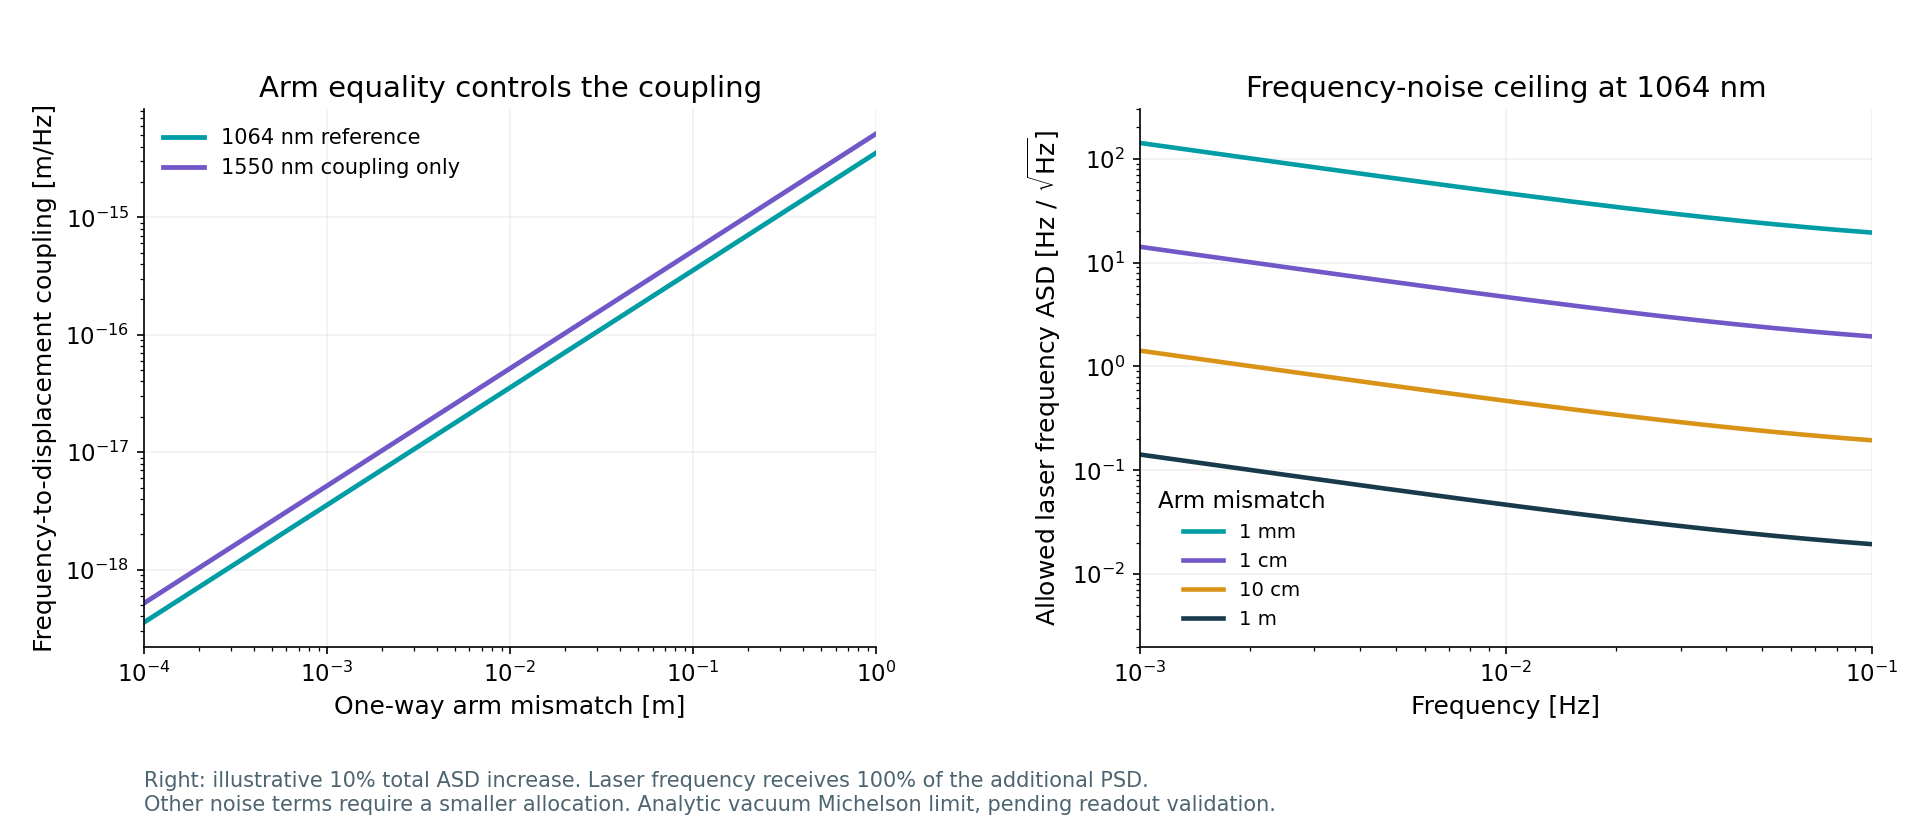

In [10]:
fig,axs=plt.subplots(1,2,figsize=(12.8,5.6))
dm=np.geomspace(1e-4,1,300)
for wavelength,label,color in [(1064e-9,'1064 nm reference','#009DA4'),
                                (1550e-9,'1550 nm coupling only','#7157C7')]:
    axs[0].loglog(dm,abs(frequency_coupling_m_per_Hz(dm,wavelength)),label=label,color=color,lw=2.3)
axs[0].set(xlabel='One-way arm mismatch [m]',ylabel='Frequency-to-displacement coupling [m/Hz]',
           title='Arm equality controls the coupling',xlim=(1e-4,1))
axs[0].legend(frameon=False,fontsize=10)
for delta,label,color in zip(mismatches_m,['1 mm','1 cm','10 cm','1 m'],
                             ['#009DA4','#7157C7','#D99418','#183A4A']):
    limit=max_frequency_asd(relative_allowance,delta,P['wavelength_m'],allocation_fraction)
    axs[1].loglog(fb,limit,label=label,color=color,lw=2.2)
axs[1].set(xlabel='Frequency [Hz]',ylabel=r'Allowed laser frequency ASD [Hz / $\sqrt{\mathrm{Hz}}$]',
           title='Frequency-noise ceiling at 1064 nm',xlim=(1e-3,1e-1),ylim=(0.002,300))
axs[1].legend(title='Arm mismatch',frameon=False,fontsize=9.5,loc='lower left')
for ax in axs:ax.grid(True,which='major',alpha=.18)
fig.text(.075,.035,'Right: illustrative 10% total ASD increase. Laser frequency receives 100% of the additional PSD.\n'
         'Other noise terms require a smaller allocation. Analytic vacuum Michelson limit, pending readout validation.',
         fontsize=10,color='#4D6570')
fig.subplots_adjust(left=.075,right=.975,bottom=.23,top=.87,wspace=.36)
fig.savefig('iLILA_Frequency_Noise_Requirements.png',dpi=200)
plt.show()

### Readout calibration and independent derivative check

For an ideal lossless Michelson, use normalized interference power $P_0$ and operating phase $\phi_0$:

$$P_{AS}=\frac{P_0}{2}(1-\cos\phi),\quad
H_{Px}=\frac{2\pi P_0}{\lambda}\sin\phi_0,\quad
H_{P\nu}=\frac{2\pi P_0\Delta L}{c}\sin\phi_0.$$

Their ratio recovers $\Delta L/\nu_0$ wherever the direct-power readout has a nonzero linear response. At an exact dark fringe, both derivatives vanish and the ratio is undefined. A specified homodyne, heterodyne, demodulated or offset readout is needed there. This example uses quadrature solely to check the analytic derivative. It does not select quadrature as the flight design.

Finesse defines transfer functions around an operating point and permits separate signal injections. The next simulation should inject differential mirror displacement and laser-frequency modulation separately, measure both in the same readout, and compare their ratio to the analytic result. [Finesse transfer-function documentation](https://finesse.ifosim.org/docs/latest/usage/lti/signals.html), accessed 24 September 2026.

In [11]:
def power_at_phase(phi,P0=1.0):
    return P0*(1-np.cos(phi))/2

def analytic_readout_gains(phi0,delta_m,wavelength_m,P0=1.0):
    gx=2*np.pi*P0/wavelength_m*np.sin(phi0)  # W/m
    gnu=2*np.pi*P0*delta_m/C*np.sin(phi0)   # W/Hz
    return gx,gnu

phi0=np.pi/2
delta_test=.01
wave=P['wavelength_m']
gx,gnu=analytic_readout_gains(phi0,delta_test,wave)
# Evaluate independent centered differences of the nonlinear power response.
phase_step=1e-5
dx=phase_step*wave/(4*np.pi)
dnu=phase_step*C/(4*np.pi*delta_test)
gx_fd=(power_at_phase(phi0+4*np.pi*dx/wave)-power_at_phase(phi0-4*np.pi*dx/wave))/(2*dx)
gnu_fd=(power_at_phase(phi0+4*np.pi*delta_test*dnu/C)-power_at_phase(phi0-4*np.pi*delta_test*dnu/C))/(2*dnu)
np.testing.assert_allclose([gx_fd,gnu_fd],[gx,gnu],rtol=1e-8,atol=0)
np.testing.assert_allclose(gnu_fd/gx_fd,frequency_coupling_m_per_Hz(delta_test,wave),rtol=1e-8,atol=0)
assert analytic_readout_gains(0,delta_test,wave)==(0.0,0.0)
assert frequency_coupling_m_per_Hz(0,wave)==0
np.testing.assert_allclose(frequency_coupling_m_per_Hz(.1,wave)/frequency_coupling_m_per_Hz(.01,wave),10)
np.testing.assert_allclose(max_frequency_asd(1e-16,.01,wave,.25)/max_frequency_asd(1e-16,.01,wave,1),.5)
print(f'Quadrature H_Px = {gx:.6e} W/m for P0 = 1 W normalization')
print(f'Quadrature H_Pnu = {gnu:.6e} W/Hz for a 1 cm mismatch')
print(f'Ratio = {gnu/gx:.6e} m/Hz')
print(f'Largest round-trip propagation phase across 1–100 mHz: '
      f'{2*np.pi*.1*2*P["arm_length_m"]/C:.3e} rad')
print('Passed: nonlinear finite-difference response, coupling ratio, equal-arm limit,')
print('mismatch scaling and PSD-allocation scaling. Finesse comparison is pending.')

Quadrature H_Px = 5.905249e+06 W/m for P0 = 1 W normalization
Quadrature H_Pnu = 2.095845e-10 W/Hz for a 1 cm mismatch
Ratio = 3.549122e-17 m/Hz
Largest round-trip propagation phase across 1–100 mHz: 4.192e-06 rad
Passed: nonlinear finite-difference response, coupling ratio, equal-arm limit,
mismatch scaling and PSD-allocation scaling. Finesse comparison is pending.


### What this adds to the project

At 10 mHz, the illustrative 10% ASD envelope gives an extra displacement ASD ceiling of about $1.66\times10^{-16}$ m/√Hz. If it were entirely allocated to laser-frequency noise, a **1 cm mismatch at 1064 nm** would require about **4.67 Hz/√Hz or less**. A 10 cm mismatch tightens that ceiling by a factor of ten. These statements depend on the reference coordinate and the chosen envelope; they are not hardware specifications.

The required laser temperature spectrum can later follow from $A_{\nu,T}(f)=|H_{\nu T}(f)|A_T(f)$. We need a measured or supported $H_{\nu T}$ and the stabilization loop before assigning numbers. A slow frequency drift history should be propagated separately to the operating phase.

**Next decision for the optical model:** specify the laboratory readout and operating point. Then validate $H_{Px}$ and $H_{P\nu}$ in Finesse and replace the ceiling study with the measured or specified laser spectrum. In parallel, obtain Teviet's numerical mode table for the resonant strain and SNR calculation.

**Update:** The user authorized hypothetical alternatives rather than choosing a readout. The comparison below carries all three cases forward.

## Readout alternatives — APRA-informed hypothetical comparison

**Decision:** carry direct intensity, balanced homodyne and heterodyne readouts forward without assigning an unconfirmed bench configuration. Calculations below are executed analytic models, not Finesse simulations or measured hardware performance.

The supplied **apra_Interferometer - V1.pdf**, page 3, shows a Michelson with one detector. Pages 6 and 8 specify 1550 nm collimation/isolation; page 9 names an **APD410C**, an InGaAs avalanche photodetector with a stated DC–10 MHz bandwidth. No separate local oscillator, second detection channel, frequency shifter or demodulator appears in the drawing. **Inference:** direct intensity detection is the closest match to that drawing; the slides do not establish its operating phase or rule out later modifications.

We use APRA only to motivate a **1550 nm bench example**. Its dimensions, optical power and detector noise are not transferred to the 1 km iLILA reference. The previous 1064 nm thermal/shot/dust baseline is retained as originally calculated.

| Quantity | Hypothetical assumption |
|---|---|
| Displacement | $x=\delta L_X-\delta L_Y$, one-way differential motion |
| Optical phase | $\phi=4\pi x/\lambda$; vacuum, quasistatic propagation |
| $P_r$ | Total returning power available across both ideal Michelson output ports, before detector quantum efficiency; not laser launch power |
| Main example | $\lambda=1550$ nm, $P_r=100$ nW, $\eta=0.80$ |
| LO power | $P_{LO}=100$ nW at the homodyne combiner; independent of $P_r$ |
| Detection | Ideal unity-gain photodiodes for the optical shot-noise benchmark, perfect visibility, no squeezing |
| Frequency coupling | Illustrative static one-way arm mismatch $\Delta L=1$ cm, same laser, no additional reference-path noise |
| Heterodyne | Single frequency-shifted LO, ideal balanced receiver, one real demodulated quadrature; ideal flat response across its sidebands |

Neither the efficiency nor these powers are APD410C specifications. The APD requires its own excess noise, gain, dark/electronic noise and linearity model. Power sweeps below are mathematical optical benchmarks, not approved APD operating ranges.

### One coordinate, three calibrated signals

Let $k=4\pi/\lambda$ and $\epsilon=h c/\lambda$. All noise PSDs below are **one-sided**; gains are expressed as equivalent optical power per displacement. The same responsivity would multiply both the signal and optical noise in a current or voltage readout.

**A. One photodiode, direct intensity.**

$$P_d=P_r\sin^2(\phi/2),\quad G_{Dx}=\frac{P_r k}{2}\sin\phi_0,\quad
S_{P,D}=\frac{2\epsilon P_d}{\eta}.$$

At quadrature ($\phi_0=\pi/2$),

$$A_{x,D}=\frac{2}{k}\sqrt{\frac{\epsilon}{\eta P_r}}.$$

The **exact dark fringe has zero linear intensity gain**. For a nonzero offset approaching dark, the ideal shot-only sensitivity tends to $\sqrt{2}\sqrt{\epsilon/(\eta P_r)}/k$. That limiting expression is not a calibrated measurement at zero offset. Any additive detector noise becomes increasingly important as the slope vanishes.

**B. Balanced homodyne at dark.** Choose a fixed-common-phase convention for the dark-port field $E_s=i\sqrt{P_r}\sin(\phi/2)$ and an LO aligned with the signal quadrature. A 50:50 combiner and subtraction of its two photodiode powers give

$$D_H=2\sqrt{P_{LO}P_r}\sin(\phi/2),\quad
G_{Hx}=k\sqrt{P_{LO}P_r},\quad
S_{P,H}=\frac{2\epsilon P_{LO}}{\eta}\quad(\phi_0=0).$$

$$A_{x,H}=\frac{\sqrt{2}}{k}\sqrt{\frac{\epsilon}{\eta P_r}}.$$

This senses the field linearly at a dark Michelson output. Increasing the LO raises both signal and shot noise, leaving this optical limit unchanged. It can improve clearance above electronics noise until other receiver limits matter. LO power is an **additional optical resource** and is not charged against fixed $P_r$ in this comparison.

**C. Heterodyne at dark.** A single frequency-shifted LO gives $D_{RF}=D_H\cos\Omega t$. Define the calibrated demodulator as $\mathrm{LPF}[2D_{RF}\cos\Omega t]$, so its signal gain is $G_{Hx}$. White noise around both RF sidebands folds into the baseband: $S_{P,het}=2S_{P,H}$, giving

$$A_{x,het}=\sqrt{2}\,A_{x,H}=A_{x,D}\text{ at quadrature}.$$

This $\sqrt{2}$ ASD penalty applies to the specified single-tone, real-quadrature scheme; it is not a universal factor for every heterodyne topology. An RF beat and demodulation can move detection away from baseband electronics noise, but do not remove low-frequency physical arm motion or laser-frequency noise.

For all three nonzero calibrated gains,

$$\frac{G_{r\nu}}{G_{rx}}=\frac{\Delta L}{\nu_0},\qquad \nu_0=c/\lambda.$$

Changing the ideal readout **does not relax arm-mismatch coupling**. Additional LO/reference-path and RF oscillator noise would add new terms in a real implementation. For a one-arm rather than pure differential injection, common optical phase changes too; the same first-order dark-port result follows because the carrier field there vanishes.

In [12]:
R = dict(wavelength_m=1550e-9, return_power_W=100e-9, eta=0.80,
         lo_power_W=100e-9, mismatch_m=0.01)
kr=4*np.pi/R['wavelength_m']
eph=H*C/R['wavelength_m']

def readout_limits(return_power, wavelength=1550e-9, eta=.8):
    pr=np.asarray(return_power,dtype=float)
    if np.any(pr<=0) or not 0<eta<=1 or wavelength<=0:
        raise ValueError('Positive powers/wavelength and 0 < eta <= 1 required.')
    k=4*np.pi/wavelength
    hom=np.sqrt(2*H*C/wavelength/(eta*pr))/k
    return {'Direct (quadrature)':np.sqrt(2)*hom,
            'Balanced homodyne (dark)':hom,
            'Heterodyne (dark, single-tone)':np.sqrt(2)*hom}

readout_rows=[]
for wavelength in [1064e-9,1550e-9]:
    for name,asd in readout_limits(R['return_power_W'],wavelength,R['eta']).items():
        readout_rows.append(dict(wavelength_nm=round(wavelength*1e9),readout=name,
                                 shot_ASD_m_rtHz=float(asd),
                                 frequency_coupling_m_Hz=float(frequency_coupling_m_per_Hz(R['mismatch_m'],wavelength))))
readout_table=pd.DataFrame(readout_rows)
print('Optical shot-noise benchmark only: Pr=100 nW, eta=0.80, unity-gain ideal detectors.')
print(readout_table.to_string(index=False,float_format=lambda v:f'{v:.5g}'))
print('1064 nm rows vary wavelength only; they do not rerun or renormalize the paper budget.')
readout_table.to_csv('iLILA_Readout_Comparison.csv',index=False)

pr=R['return_power_W']; plo=R['lo_power_W']
gdirect=pr*kr/2
ghom=kr*np.sqrt(pr*plo)
hnu=frequency_coupling_m_per_Hz(R['mismatch_m'],R['wavelength_m'])
print(f'1550 nm direct quadrature: Gx={gdirect:.6g} W/m; Gnu={gdirect*hnu:.6g} W/Hz')
print(f'1550 nm homodyne/normalized heterodyne: Gx={ghom:.6g} W/m; Gnu={ghom*hnu:.6g} W/Hz')

Optical shot-noise benchmark only: Pr=100 nW, eta=0.80, unity-gain ideal detectors.
 wavelength_nm                        readout  shot_ASD_m_rtHz  frequency_coupling_m_Hz
          1064            Direct (quadrature)       2.5869e-13               3.5491e-17
          1064       Balanced homodyne (dark)       1.8292e-13               3.5491e-17
          1064 Heterodyne (dark, single-tone)       2.5869e-13               3.5491e-17
          1550            Direct (quadrature)       3.1223e-13               5.1702e-17
          1550       Balanced homodyne (dark)       2.2078e-13               5.1702e-17
          1550 Heterodyne (dark, single-tone)       3.1223e-13               5.1702e-17
1064 nm rows vary wavelength only; they do not rerun or renormalize the paper budget.
1550 nm direct quadrature: Gx=0.405367 W/m; Gnu=2.09585e-17 W/Hz
1550 nm homodyne/normalized heterodyne: Gx=0.810734 W/m; Gnu=4.19169e-17 W/Hz


### Operating point and shot-noise comparison

The first plot shows why direct detection needs a fringe offset and a calibrated slope. The second compares ideal shot noise at equal returning power. Balanced homodyne has $1/\sqrt{2}$ the ASD of a **single-port direct readout at quadrature** under these assumptions. This is not an inherent advantage over every direct scheme: ideal direct detection close to dark approaches the same shot-only limit, and subtraction of both Michelson output intensities at quadrature also reaches it.

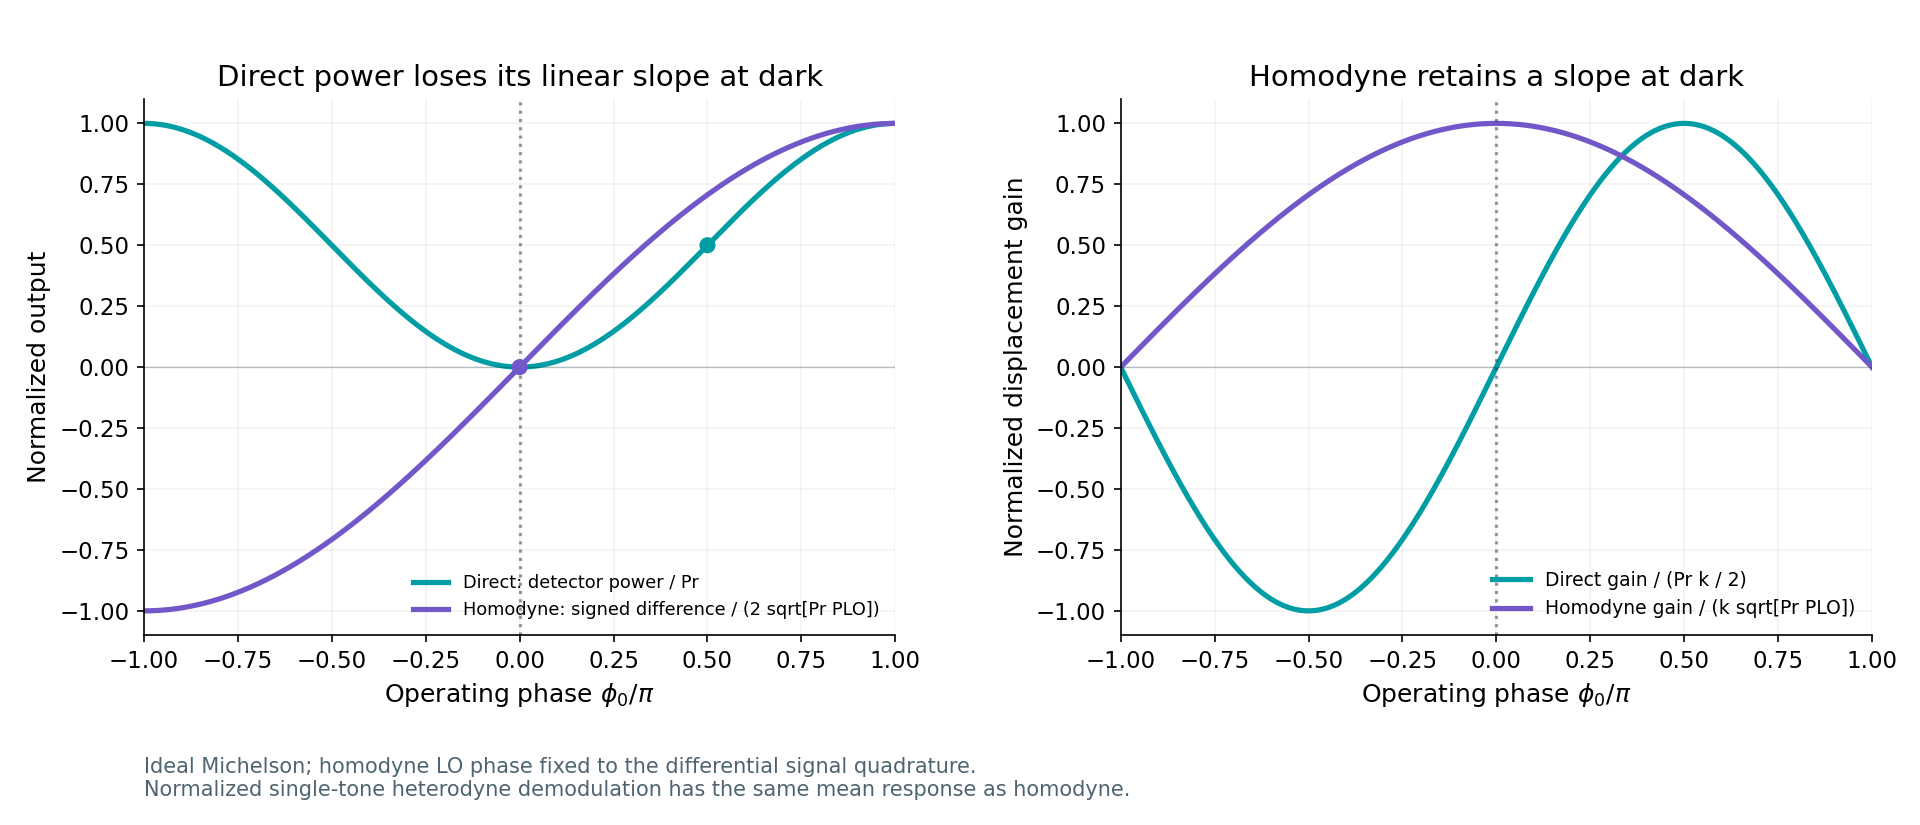

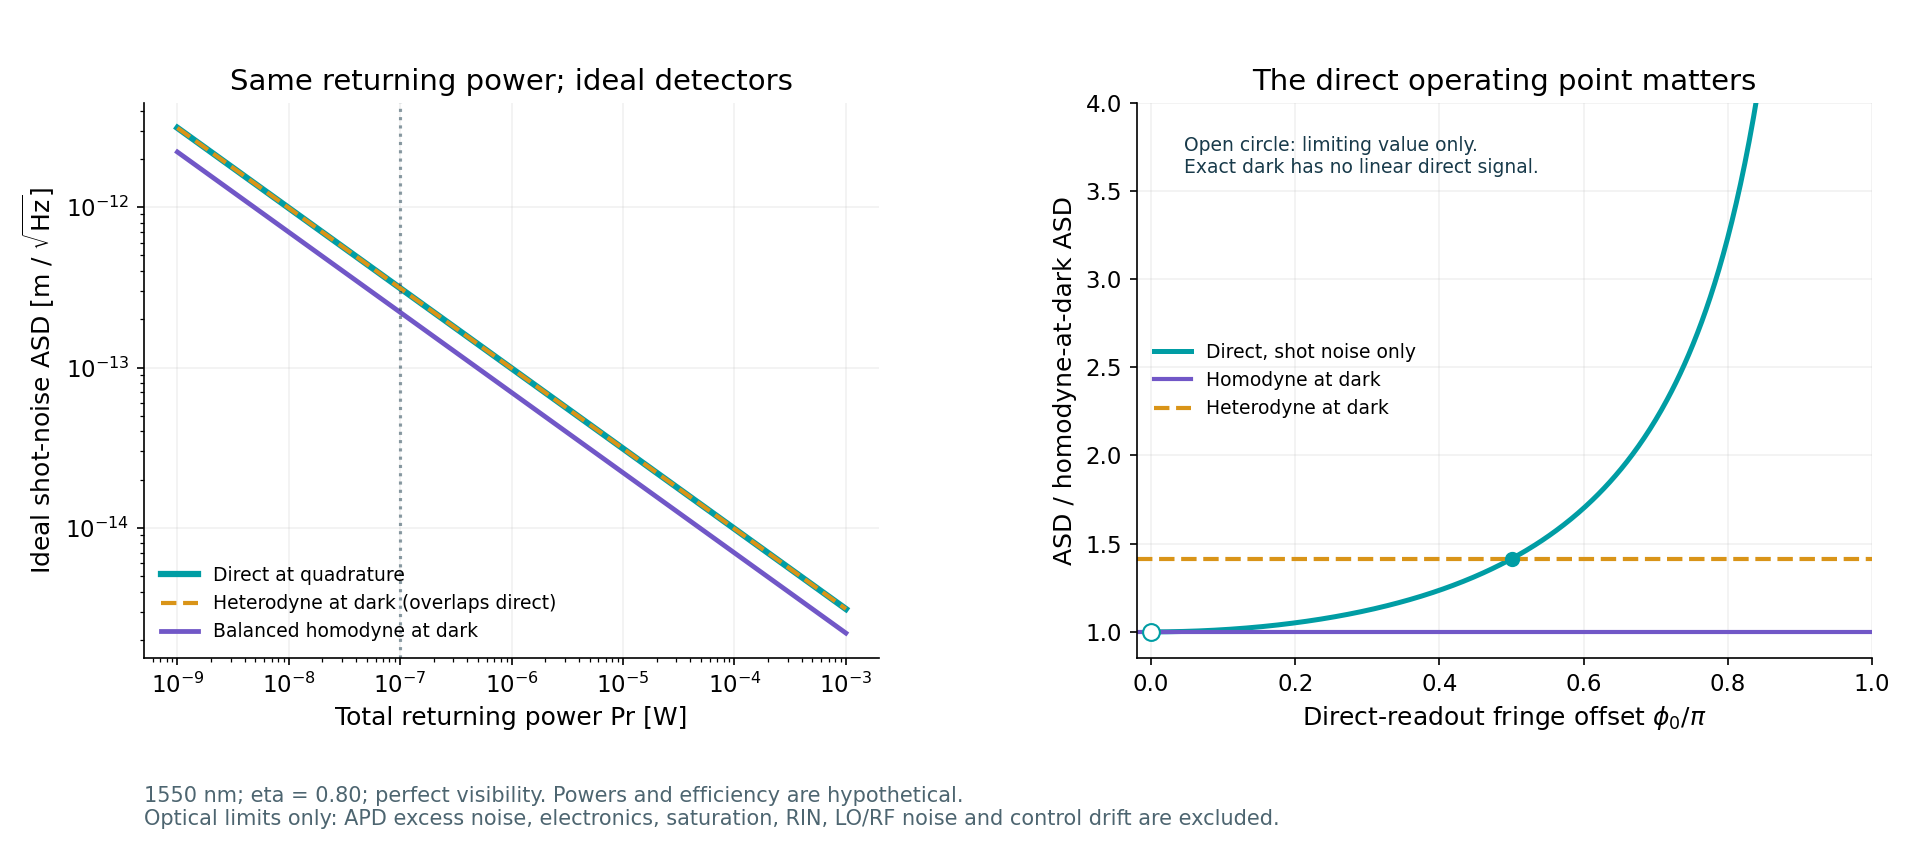

In [13]:
teal='#009DA4'; purple='#7157C7'; orange='#D99418'; navy='#183A4A'
phi=np.linspace(-np.pi,np.pi,1001)
fig,axs=plt.subplots(1,2,figsize=(12.8,5.5))
axs[0].plot(phi/np.pi,np.sin(phi/2)**2,color=teal,lw=2.5,label='Direct: detector power / Pr')
axs[0].plot(phi/np.pi,np.sin(phi/2),color=purple,lw=2.5,label='Homodyne: signed difference / (2 sqrt[Pr PLO])')
axs[0].scatter([0,.5],[0,.5],s=45,color=[purple,teal],zorder=5)
axs[0].set(xlabel=r'Operating phase $\phi_0 / \pi$',ylabel='Normalized output',
           title='Direct power loses its linear slope at dark',xlim=(-1,1))
axs[0].legend(frameon=False,fontsize=8.5,loc='lower right')
axs[1].plot(phi/np.pi,np.sin(phi),color=teal,lw=2.5,label='Direct gain / (Pr k / 2)')
axs[1].plot(phi/np.pi,np.cos(phi/2),color=purple,lw=2.5,label='Homodyne gain / (k sqrt[Pr PLO])')
axs[1].set(xlabel=r'Operating phase $\phi_0 / \pi$',ylabel='Normalized displacement gain',
           title='Homodyne retains a slope at dark',xlim=(-1,1))
axs[1].legend(frameon=False,fontsize=9,loc='lower right')
for ax in axs:
    ax.axvline(0,color=navy,ls=':',alpha=.5);ax.axhline(0,color=navy,lw=.6,alpha=.3)
    ax.grid(alpha=.15)
fig.text(.075,.035,'Ideal Michelson; homodyne LO phase fixed to the differential signal quadrature.\n'
         'Normalized single-tone heterodyne demodulation has the same mean response as homodyne.',fontsize=10,color='#4D6570')
fig.subplots_adjust(left=.075,right=.975,bottom=.23,top=.88,wspace=.30)
fig.savefig('iLILA_Readout_Operating_Points.png',dpi=200)
plt.show()

fig,axs=plt.subplots(1,2,figsize=(12.8,5.7))
pr_sweep=np.geomspace(1e-9,1e-3,400)
lim=readout_limits(pr_sweep)
axs[0].loglog(pr_sweep,lim['Direct (quadrature)'],color=teal,lw=3,label='Direct at quadrature')
axs[0].loglog(pr_sweep,lim['Heterodyne (dark, single-tone)'],color=orange,lw=2,ls='--',label='Heterodyne at dark (overlaps direct)')
axs[0].loglog(pr_sweep,lim['Balanced homodyne (dark)'],color=purple,lw=2.3,label='Balanced homodyne at dark')
axs[0].axvline(pr,color=navy,ls=':',alpha=.5)
axs[0].set(xlabel='Total returning power Pr [W]',ylabel=r'Ideal shot-noise ASD [m / $\sqrt{\mathrm{Hz}}$]',
           title='Same returning power; ideal detectors')
axs[0].legend(frameon=False,fontsize=9,loc='lower left')
off=np.linspace(.001,np.pi*.995,500)
axs[1].plot(off/np.pi,1/np.abs(np.cos(off/2)),color=teal,lw=2.4,label='Direct, shot noise only')
axs[1].axhline(1,color=purple,lw=2,label='Homodyne at dark')
axs[1].axhline(np.sqrt(2),color=orange,lw=2,ls='--',label='Heterodyne at dark')
axs[1].scatter([.5],[np.sqrt(2)],color=teal,s=40,zorder=5)
axs[1].scatter([0],[1],s=65,facecolor='white',edgecolor=teal,zorder=6)
axs[1].set(xlabel=r'Direct-readout fringe offset $\phi_0 / \pi$',ylabel='ASD / homodyne-at-dark ASD',
           title='The direct operating point matters',xlim=(-.02,1),ylim=(.85,4))
axs[1].text(.045,3.6,'Open circle: limiting value only.\nExact dark has no linear direct signal.',fontsize=9,color=navy)
axs[1].legend(frameon=False,fontsize=9,loc='center left')
for ax in axs:ax.grid(True,which='major',alpha=.18)
fig.text(.075,.035,'1550 nm; eta = 0.80; perfect visibility. Powers and efficiency are hypothetical.\n'
         'Optical limits only: APD excess noise, electronics, saturation, RIN, LO/RF noise and control drift are excluded.',fontsize=10,color='#4D6570')
fig.subplots_adjust(left=.075,right=.975,bottom=.23,top=.88,wspace=.35)
fig.savefig('iLILA_Readout_Shot_Noise_Comparison.png',dpi=200)
plt.show()

### Validate gains, the demodulation normalization, and the noise factor

Centered differences of nonlinear optical fields independently check the analytic gains for displacement and laser frequency. A sampled RF beat checks the $2\cos\Omega t$ demodulator, and its noise weighting checks the factor of two in PSD. These tests do not validate a detector model, Finesse syntax, or a real servo.

In [14]:
# Nonlinear optical powers, expressed in W. Use complex fields at the BHD combiner.
def direct_signal(phase):
    return pr*np.sin(phase/2)**2
def homodyne_signal(phase):
    es=1j*np.sqrt(pr)*np.sin(phase/2)
    elo=1j*np.sqrt(plo)
    return np.abs((es+elo)/np.sqrt(2))**2-np.abs((es-elo)/np.sqrt(2))**2

phase_step=1e-5
dx=phase_step/kr
dnu=phase_step/(kr*hnu)
for name,fn,bias,gain in [('direct',direct_signal,np.pi/2,gdirect),
                          ('homodyne',homodyne_signal,0,ghom)]:
    gx_num=(fn(bias+kr*dx)-fn(bias-kr*dx))/(2*dx)
    gn_num=(fn(bias+kr*hnu*dnu)-fn(bias-kr*hnu*dnu))/(2*dnu)
    np.testing.assert_allclose(gx_num,gain,rtol=1e-8,atol=0)
    np.testing.assert_allclose(gn_num/gx_num,hnu,rtol=1e-8,atol=0)
    print(f'{name}: independent nonlinear Gx={gx_num:.6g} W/m; Gnu/Gx={gn_num/gx_num:.6g} m/Hz')
np.testing.assert_equal(direct_signal(phase_step),direct_signal(-phase_step))

# Arbitrary dimensionless RF sampling: exact whole cycles, no proposed hardware IF.
theta=2*np.pi*13*np.arange(8192)/8192
mix=2*np.cos(theta)
def heterodyne_demod(phase):
    return np.mean(homodyne_signal(phase)*np.cos(theta)*mix)
ghet=(heterodyne_demod(phase_step)-heterodyne_demod(-phase_step))/(2*dx)
np.testing.assert_allclose(ghet,ghom,rtol=1e-8,atol=0)
np.testing.assert_allclose(np.mean(mix**2),2,rtol=1e-12,atol=0)
# White independent RF noise is weighted by mix; variance = sigma^2 sum(mix^2)/N^2.
# Relative to unmodulated averaging its variance doubles, hence ASD grows sqrt(2).
shot_d=np.sqrt(2*eph*direct_signal(np.pi/2)/R['eta'])/gdirect
shot_h=np.sqrt(2*eph*plo/R['eta'])/ghom
expected=readout_limits(pr)
np.testing.assert_allclose([shot_d,shot_h],
    [expected['Direct (quadrature)'],expected['Balanced homodyne (dark)']],rtol=1e-12,atol=0)
np.testing.assert_allclose(shot_d/shot_h,np.sqrt(2),rtol=1e-12,atol=0)
np.testing.assert_allclose(readout_limits(4*pr)['Direct (quadrature)']/shot_d,.5,rtol=1e-12,atol=0)
# Same fixed return power and efficiency: shot ASD scales sqrt(wavelength).
np.testing.assert_allclose(readout_limits(pr,1550e-9)['Direct (quadrature)']/
    readout_limits(pr,1064e-9)['Direct (quadrature)'],np.sqrt(1550/1064),rtol=1e-12,atol=0)
print('Passed: direct/homodyne nonlinear gains, frequency coupling ratios, dark direct null,')
print('RF-demodulated gain, two-sideband noise factor, shot normalization and power/wavelength scaling.')

direct: independent nonlinear Gx=0.405367 W/m; Gnu/Gx=5.17024e-17 m/Hz
homodyne: independent nonlinear Gx=0.810734 W/m; Gnu/Gx=5.17024e-17 m/Hz
Passed: direct/homodyne nonlinear gains, frequency coupling ratios, dark direct null,
RF-demodulated gain, two-sideband noise factor, shot normalization and power/wavelength scaling.


### Include real detector and technical noise without guessing it

For a direct APD, let $F(M)\geq1$ be the avalanche excess-noise factor at gain $M$ and let $N_D(f)$ be the independently characterized **dark/electronic optical-input-referred ASD**, excluding illumination shot noise. Then

$$S_{x,D}(f)=\frac{2\epsilon F(M)P_d/\eta+N_D^2(f)}{|G_{Dx}|^2}.$$

Avalanche multiplication amplifies the signal and primary photocurrent noise together; it is not equivalent to increasing detected optical power. If a measured total noise spectrum already contains illumination noise, use that total divided by gain and do not add shot noise again. A quoted broadband minimum NEP alone does not establish the 1–100 mHz spectrum.

For an ideal balanced receiver at dark, with independent per-diode input-referred electronics ASDs $N_1,N_2$,

$$S_{x,H}=\frac{2\epsilon P_{LO}/\eta+N_1^2+N_2^2}{k^2P_{LO}P_r}.$$

If the diode electronics noises are correlated, their cross spectrum must be retained when subtracting currents. An APD implementation also needs the appropriate multiplication noise. For the specified heterodyne, the two RF-sideband noise PSDs must be propagated through the demodulator; the factor of two applies only when those sidebands have equal, flat noise.

At direct quadrature, common returning-power RIN gives

$$A_{x,RIN}=A_{RIN}/k.$$

Ideal homodyne at an exactly dark port has no first-order offset signal from common amplitude changes. Real contrast defects, unequal gains, mode mismatch and residual carrier leakage reintroduce couplings. LO phase error $\psi$ reduces its signal gain by $\cos\psi$; time-dependent LO/reference phase and RF oscillator noise must be computed from the actual paths and leakage. A single direct detector can also measure a heterodyne beat after appropriate optical/RF additions; the balanced architecture here is a specific hypothetical alternative, not a claim that two detectors are always required for heterodyne.

| Case | Hardware/operating condition to model next |
|---|---|
| Direct | APD gain, measured fringe contrast/power, nonzero fringe offset or quadrature servo, calibrated voltage slope and dark noise |
| Balanced homodyne | LO pickoff and path, combiner, matched detection channels/subtraction, quadrature control, LO power and leakage |
| Heterodyne | LO frequency shift, beat frequency and sidebands within receiver bandwidth, RF source noise, demodulation phase/filter, receiver balance |

We can keep both architecture branches open while using the direct APRA layout as a bench reference. No readout choice is needed to retain the laser-frequency mismatch limit.

In [15]:
print('Illustrative detector-noise sensitivity at 1550 nm, Pr=100 nW:')
print(f'Direct quadrature: 1e-13 W/rtHz of additive input-referred detector noise would give {1e-13/gdirect:.4g} m/rtHz.')
print('That noise value is an arbitrary sensitivity example, NOT an APD410C specification.')
print(f'RIN coupling at quadrature: {1/kr:.4g} m per fractional power change.')
print(f'1 cm mismatch: A_x,nu = {abs(hnu):.5g} A_nu (m/rtHz for A_nu in Hz/rtHz), in all three ideal readouts.')

Illustrative detector-noise sensitivity at 1550 nm, Pr=100 nW:
Direct quadrature: 1e-13 W/rtHz of additive input-referred detector noise would give 2.467e-13 m/rtHz.
That noise value is an arbitrary sensitivity example, NOT an APD410C specification.
RIN coupling at quadrature: 1.233e-07 m per fractional power change.
1 cm mismatch: A_x,nu = 5.1702e-17 A_nu (m/rtHz for A_nu in Hz/rtHz), in all three ideal readouts.


### Result and connection to the original allowance

At **1550 nm, 100 nW returning power and 80% quantum efficiency**, the hypothetical ideal optical limits are approximately **$3.12\times10^{-13}$ m/√Hz** for direct quadrature or the specified heterodyne, and **$2.21\times10^{-13}$ m/√Hz** for balanced homodyne at dark. These are optical benchmarks only, not APRA performance claims or iLILA targets.

The readout comparison does not resolve the original **1 mHz thermal excess**. It also does not create extra seismic margin by itself. A future instrument-specific readout model must **replace** the existing reference shot term when computing a revised total; adding both shot terms would double count it. The manuscript's effective-power convention must first be reconciled with $P_r$, port choice, detection efficiency and the differential coordinate used here. Do not mix the hypothetical 1550 nm bench values into the 1064 nm lunar curve.

**Next concrete calculation:** populate measured or selected detector/laser parameters, calculate the same displacement and laser-frequency transfer functions for both readout branches in Finesse, and compare them with these analytic benchmarks. Until then, maintain parameter sweeps for unknown inputs rather than inventing detector noise or seismic suppression.

Sources: supplied *apra_Interferometer - V1.pdf*, pages 3, 6, 8–9; the manuscript and frequency-coupling note cited above. The current [Finesse balanced-homodyne API](https://finesse.ifosim.org/docs/latest/api/finesse.detectors.bhd_detector.html) describes the combiner and two-photodiode subtraction with LO power and phase parameters (accessed 24 September 2026). The equations and factors in this section are derived explicitly above; Finesse has not been executed.